In [6]:
import pandas as pd
import ast
import re

In [9]:
with open("trials-data/suggest-units1-dorpout1-activationl1_7.txt", "r") as file:
    lines = [line.strip() for line in file if "prune" not in line]
    lines = lines[1:]
    # lines = [line.strip().split(":", 3)[3] for line in lines]
    # lines = [line.strip().rsplit(".", 3)[0] for line in lines]
    # lines = [line.strip().split(":", 1) for line in lines]
    # lines = [line[0].strip().split(" ", 1)[0] for line in lines]

In [10]:
logs = lines.copy()

# Extract values using regex
data = []
for log in logs:
    value_match = re.search(r"finished with value: ([\d\.]+)", log)  # Extract value
    params_match = re.search(r"parameters: ({.*?})", log)  # Extract dictionary

    if value_match and params_match:
        value = float(value_match.group(1))  # Convert to float
        params = ast.literal_eval(params_match.group(1))  # Convert string dict to real dict
        data.append({"val_accuracy": value, **params})  # Merge dicts

# Convert to DataFrame
df = pd.DataFrame(data).sort_values(["val_accuracy"],ascending=False)
df.to_excel("trials-data/suggest-units1-dorpout1-activationl1_7.xlsx", index=False)

display(df)

,val_accuracy,n_units_l0,dropout_l0,n_units_l1,dropout_l1,learning_rate
33,0.896125,87,0.367179,61,0.223022,0.000040
6,0.895865,95,0.259494,53,0.206731,0.000021
12,0.894567,90,0.302618,67,0.297240,0.000044
64,0.893788,83,0.335319,73,0.237096,0.000034
84,0.891702,92,0.374345,61,0.206594,0.000029
...,...,...,...,...,...,...
86,0.844952,98,0.411030,60,0.227116,0.000024
45,0.841327,80,0.491273,54,0.211499,0.000051
21,0.832462,91,0.290329,59,0.233509,0.000045
40,0.801019,85,0.362581,61,0.294219,0.000062


In [1]:
import urllib
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import numpy as np
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install numpy==2.1.3
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install matplotlib==3.10.0
    import matplotlib.pyplot as plt

try:
    import sklearn
    import sklearn.datasets
    import sklearn.linear_model
    from sklearn.model_selection import train_test_split
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install scikit-learn==1.6.1
    import sklearn
    import sklearn.datasets
    import sklearn.linear_model
    from sklearn.model_selection import train_test_split

try:
    import h5py
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install h5py==3.13.0
    import h5py

try:
    import optuna
    from optuna.trial import TrialState
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install optuna==4.2.1
    import optuna
    from optuna.trial import TrialState

try:
    from optuna.integration import KerasPruningCallback
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install optuna-integration[keras]==4.2.1
    from optuna.integration import KerasPruningCallback

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras import layers
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install tensorflow==2.19.0
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras import layers
    
try:
    import keras
    from keras.utils import to_categorical
    from keras.layers import Dense
    from keras.layers import Dropout
    from keras.models import Sequential
    from keras.optimizers import RMSprop
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install keras==3.9.0
    import keras
    from keras.utils import to_categorical
    from keras.layers import Dense
    from keras.layers import Dropout
    from keras.models import Sequential
    from keras.optimizers import RMSprop

try:
    import cv2
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install opencv-python==4.11.0.86

%matplotlib inline

2025-03-21 13:21:53.796526: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-21 13:21:53.801658: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-21 13:21:53.823483: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-21 13:21:53.851911: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742581313.880853 1602191 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742581313.88

In [2]:
from ImportImagenes_mod import *
CE_x, CV_x, CE_y, CV_y = import_imagenes()
CE_x, CV_x, CE_y, CV_y = CE_x.T, CV_x.T, CE_y.T, CV_y.T
print(CE_y.shape)
CE_x = CE_x.astype("float32")
CV_x = CV_x.astype("float32")

print("\nEntrenamiento:")
print("CE_x shape:\n", CE_x.shape)
print("CE_y shape:\n", CE_y.shape)

print("\nValidación:")
print("CV_x shape:\n", CV_x.shape)
print("CV_y shape:\n", CV_y.shape)

Dimensión de X_train: (14700, 2600)
Dimensión de X_test: (14700, 50)
Dimensión de y_train: (1, 2600)
Dimensión de y_test: (1, 50)
(2600, 1)

Entrenamiento:
CE_x shape:
 (2600, 14700)
CE_y shape:
 (2600, 1)

Validación:
CV_x shape:
 (50, 14700)
CV_y shape:
 (50, 1)


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score

{'n_layers': 3, 'activation_l0': 'selu', 'n_units_l0': 5, 'dropout_l0': 0.420178915490353, 'activation_l1': 'selu', 'n_units_l1': 13, 'dropout_l1': 0.4489642579418174, 'activation_l2': 'elu', 'n_units_l2': 24, 'dropout_l2': 0.40270447178276747}

{'n_layers': 3, 'activation_l0': 'elu', 'n_units_l0': 9, 'dropout_l0': 0.3592689284415138, 'activation_l1': 'selu', 'n_units_l1': 12, 'dropout_l1': 0.4448910232012121, 'activation_l2': 'elu', 'n_units_l2': 21, 'dropout_l2': 0.2883524527808368, 'learning_rate': 4.7390206742505655e-05}
Last Epoch: 150
Last Training Accuracy: 0.9000
Last Validation Accuracy: 0.8600

0.8633846104145049 and parameters: {'n_layers': 2, 'activation_l0': 'elu', 'n_units_l0': 6, 'dropout_l0': 0.2868088815453722, 'activation_l1': 'elu', 'n_units_l1': 16, 'dropout_l1': 0.20505103389280682, 'learning_rate': 5.37398798756962e-05}
Epoch 83/133
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8841 - loss: 0.3411 - val_accuracy: 0.9200 - val_loss: 0.2754

0.8751153767108917 and parameters: {'n_layers': 2, 'activation_l0': 'elu', 'n_units_l0': 7, 'dropout_l0': 0.28028039733002263, 'activation_l1': 'elu', 'n_units_l1': 19, 'dropout_l1': 0.20669032313428332, 'learning_rate': 6.689344561093338e-05}. Best is trial 97 with value: 0.8751153767108917.
Epoch 132/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9049 - loss: 0.2750 - val_accuracy: 0.9000 - val_loss: 0.2641

0.8904615223407744 and parameters: {'activation_l0': 'leaky_relu', 'n_units_l0': 88, 'dropout_l0': 0.33630347783559533, 'activation_l1': 'leaky_relu', 'n_units_l1': 56, 'dropout_l1': 0.43312734761328786, 'learning_rate': 2.6119474276204012e-05}
Epoch 117/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9254 - loss: 0.2227 - val_accuracy: 0.9400 - val_loss: 0.2528

0.8960384786128996 and parameters: {'n_units_l0': 99, 'dropout_l0': 0.30748172670516327, 'n_units_l1': 37, 'dropout_l1': 0.23604484228443118, 'learning_rate': 6.362050247649443e-05}
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9469 - loss: 0.1675 - val_accuracy: 0.8400 - val_loss: 0.3170
Epoch 98/150

0.9009615540504454 and parameters: {'n_units_l0': 98, 'dropout_l0': 0.23358925980239428, 'n_units_l1': 72, 'dropout_l1': 0.2191963886074372, 'learning_rate': 3.533426167502112e-05}
Epoch 92/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9375 - loss: 0.1887 - val_accuracy: 0.9400 - val_loss: 0.2637

0.9020384728908537 and parameters: {'n_units_l0': 108, 'dropout_l0': 0.3087725007496074, 'n_units_l1': 76, 'dropout_l1': 0.28195796475963886, 'learning_rate': 2.745518225857252e-05}
Epoch 119/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9421 - loss: 0.1879 - val_accuracy: 0.9400 - val_loss: 0.2421

0.9025769114494322 and parameters: {'n_units_l0': 111, 'dropout_l0': 0.21837633172142518, 'n_units_l1': 72, 'dropout_l1': 0.3518212264364254, 'learning_rate': 3.284837571498211e-05}
Epoch 84/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9272 - loss: 0.2139 - val_accuracy: 0.9400 - val_loss: 0.2535

0.8948269173502923 and parameters: {'n_units_l0': 85, 'dropout_l0': 0.39824402846536955, 'n_units_l1': 53, 'dropout_l1': 0.24517347442851, 'learning_rate': 5.522689061838563e-05}

6 finished with value: 0.8958653748035432 and parameters: {'n_units_l0': 95, 'dropout_l0': 0.25949426935177416, 'n_units_l1': 53, 'dropout_l1': 0.20673091468287022, 'learning_rate': 2.0592062503612585e-05}
Epoch 136/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9424 - loss: 0.1788 - val_accuracy: 0.9400 - val_loss: 0.2432

Trial 34 finished with value: 0.8961249992251397 and parameters: {'n_units_l0': 87, 'dropout_l0': 0.3671787082900139, 'n_units_l1': 61, 'dropout_l1': 0.2230222977545786, 'learning_rate': 3.970161923843316e-05}
Epoch 118/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9485 - loss: 0.1563 - val_accuracy: 0.9400 - val_loss: 0.2707

Trial 52 finished with value: 0.8969038322567942 and parameters: {'n_units_l0': 83, 'dropout_l0': 0.20901297269646116, 'n_units_l1': 63, 'dropout_l1': 0.2228569761711688, 'learning_rate': 4.905280642097487e-05}
Epoch 130/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9635 - loss: 0.1066 - val_accuracy: 0.9600 - val_loss: 0.2460

Trial 72 finished with value: 0.9036442413926125 and parameters: {'n_units_l0': 94, 'dropout_l0': 0.20520874905332218, 'n_units_l1': 65, 'dropout_l1': 0.2895145611727733, 'learning_rate': 2.3779937922239732e-05}
Epoch 79/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9160 - loss: 0.2486 - val_accuracy: 0.9200 - val_loss: 0.3274

Trial 9 finished with value: 0.8906538426876067 and parameters: {'n_units_l0': 87, 'dropout_l0': 0.20249485986370916, 'n_units_l1': 51, 'dropout_l1': 0.3362935932601083, 'learning_rate': 1.2954080318144527e-05}
Epoch 86/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9197 - loss: 0.2449 - val_accuracy: 0.9200 - val_loss: 0.3726

### DA MAL LA MATRIZ DE CONFUSION

 Trial 11 finished with value: 0.913346141576767 and parameters: {'n_units_l0': 94, 'dropout_l0': 0.20052257294491335, 'n_units_l1': 69, 'dropout_l1': 0.20071377535797047, 'learning_rate': 4.8258738503947405e-05}
 Epoch 80/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9404 - loss: 0.1703 - val_accuracy: 0.8600 - val_loss: 0.3889

Trial 13 finished with value: 0.8966153979301453 and parameters: {'n_units_l0': 85, 'dropout_l0': 0.20384815069285595, 'n_units_l1': 73, 'dropout_l1': 0.21254578316441622, 'learning_rate': 1.5072828010379344e-05}

Trial 49 finished with value: 0.919692313671112 and parameters: {'n_units_l0': 85, 'dropout_l0': 0.2000762398476158, 'n_units_l1': 65, 'dropout_l1': 0.20827801097339319, 'learning_rate': 8.283112736649545e-05}. Best is trial 49 with value: 0.919692313671112.

In [16]:
act_l0 = "leaky_relu"
num_hidden_l0 = 85
dropout_l0 = 0.2000762398476158
act_l1 = "leaky_relu"
num_hidden_l1 = 65
dropout_l1 = 0.20827801097339319

learning_rate = 8.283112736649545e-05

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    "nn_model_checkpoint_epoch_{epoch:02d}.weights.h5",  # Save weights with epoch number
    save_weights_only=True,  # Saves only weights, not full model
    save_freq="epoch"  # Saves at every epoch
)

# The data is split between train and validation sets.
(x_train, y_train), (x_valid, y_valid) = (CE_x, CE_y), (CV_x, CV_y)

# We define our MLP.
model_cp = Sequential()
model_cp.add(Dense(num_hidden_l0, activation=act_l0))
model_cp.add(Dropout(rate=dropout_l0))
model_cp.add(Dense(num_hidden_l1, activation=act_l1))
model_cp.add(Dropout(rate=dropout_l1))
model_cp.add(Dense(1, activation="sigmoid"))

model_cp.compile(
        loss="binary_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )
history = model_cp.fit(
        x_train,
        y_train,
        batch_size=100,
        callbacks=[checkpoint_callback],
        epochs=150,
        validation_data=(x_valid, y_valid),
        verbose=1
    )

Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5521 - loss: 0.7264 - val_accuracy: 0.7200 - val_loss: 0.5952
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6685 - loss: 0.6241 - val_accuracy: 0.8600 - val_loss: 0.4692
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7456 - loss: 0.5476 - val_accuracy: 0.8200 - val_loss: 0.3990
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7912 - loss: 0.4993 - val_accuracy: 0.8800 - val_loss: 0.3540
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7940 - loss: 0.4836 - val_accuracy: 0.7400 - val_loss: 0.4242
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8081 - loss: 0.4628 - val_accuracy: 0.9000 - val_loss: 0.3409
Epoch 7/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8135 - loss: 0.4465 - val_accuracy: 0.9000 - val_loss: 0.3183
Epoch 8/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8313 - loss: 0.4169 - val_accuracy: 0.

Epoch 148 Training Accuracy: 0.9750
Epoch 148 Validation Accuracy: 0.9600


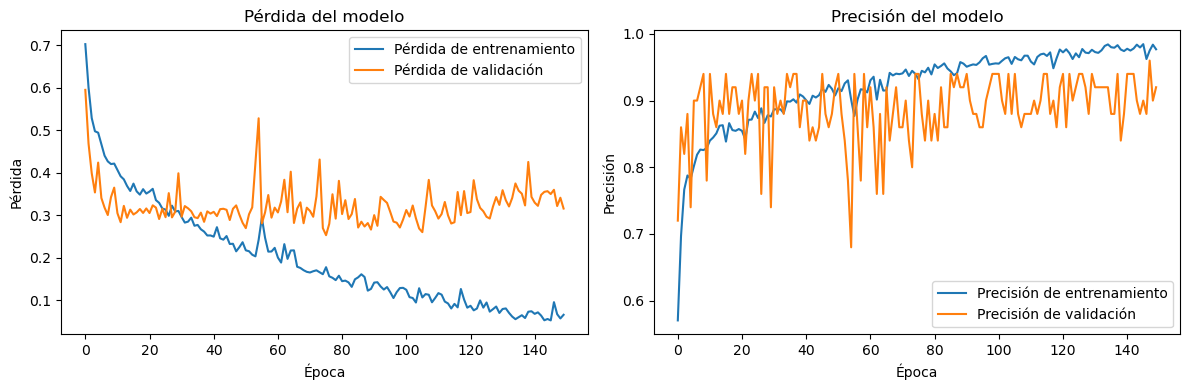

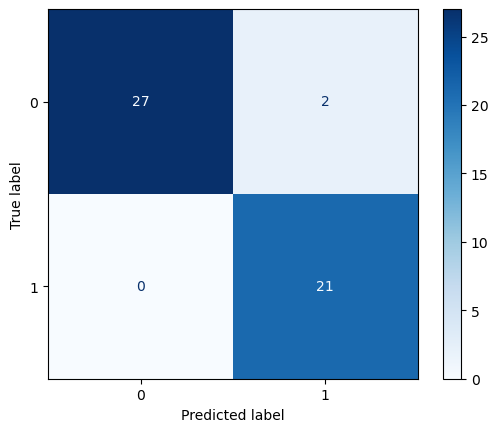

In [17]:
epoch_10 = 148  # Specify the epoch number you want

model_cp.load_weights(f"model_checkpoint_epoch_{epoch_10}.weights.h5")

# Get accuracy values at epoch 10 (index 9 because Python is 0-based)
train_accuracy_epoch_10 = history.history["accuracy"][epoch_10 - 1]
val_accuracy_epoch_10 = history.history["val_accuracy"][epoch_10 - 1]

print(f"Epoch {epoch_10} Training Accuracy: {train_accuracy_epoch_10:.4f}")
print(f"Epoch {epoch_10} Validation Accuracy: {val_accuracy_epoch_10:.4f}")


plt.figure(figsize=(12, 4))
 
# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
 
# Gráfico de precisión
plt.subplot(1, 2, 2)
if 'accuracy' in history.history:
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión del modelo')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
elif 'acc' in history.history:
    plt.plot(history.history['acc'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_acc'], label='Precisión de validación')
    plt.title('Precisión del modelo')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
 
plt.tight_layout()
plt.show()

y_pred_probs = model_cp.predict(x_valid, verbose=0)  
y_pred = (y_pred_probs > 0.5).astype(int)

y_pred_probs_t = model_cp.predict(x_train, verbose=0)  
y_pred_t = (y_pred_probs_t > 0.5).astype(int)

cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
 
plt.show() 

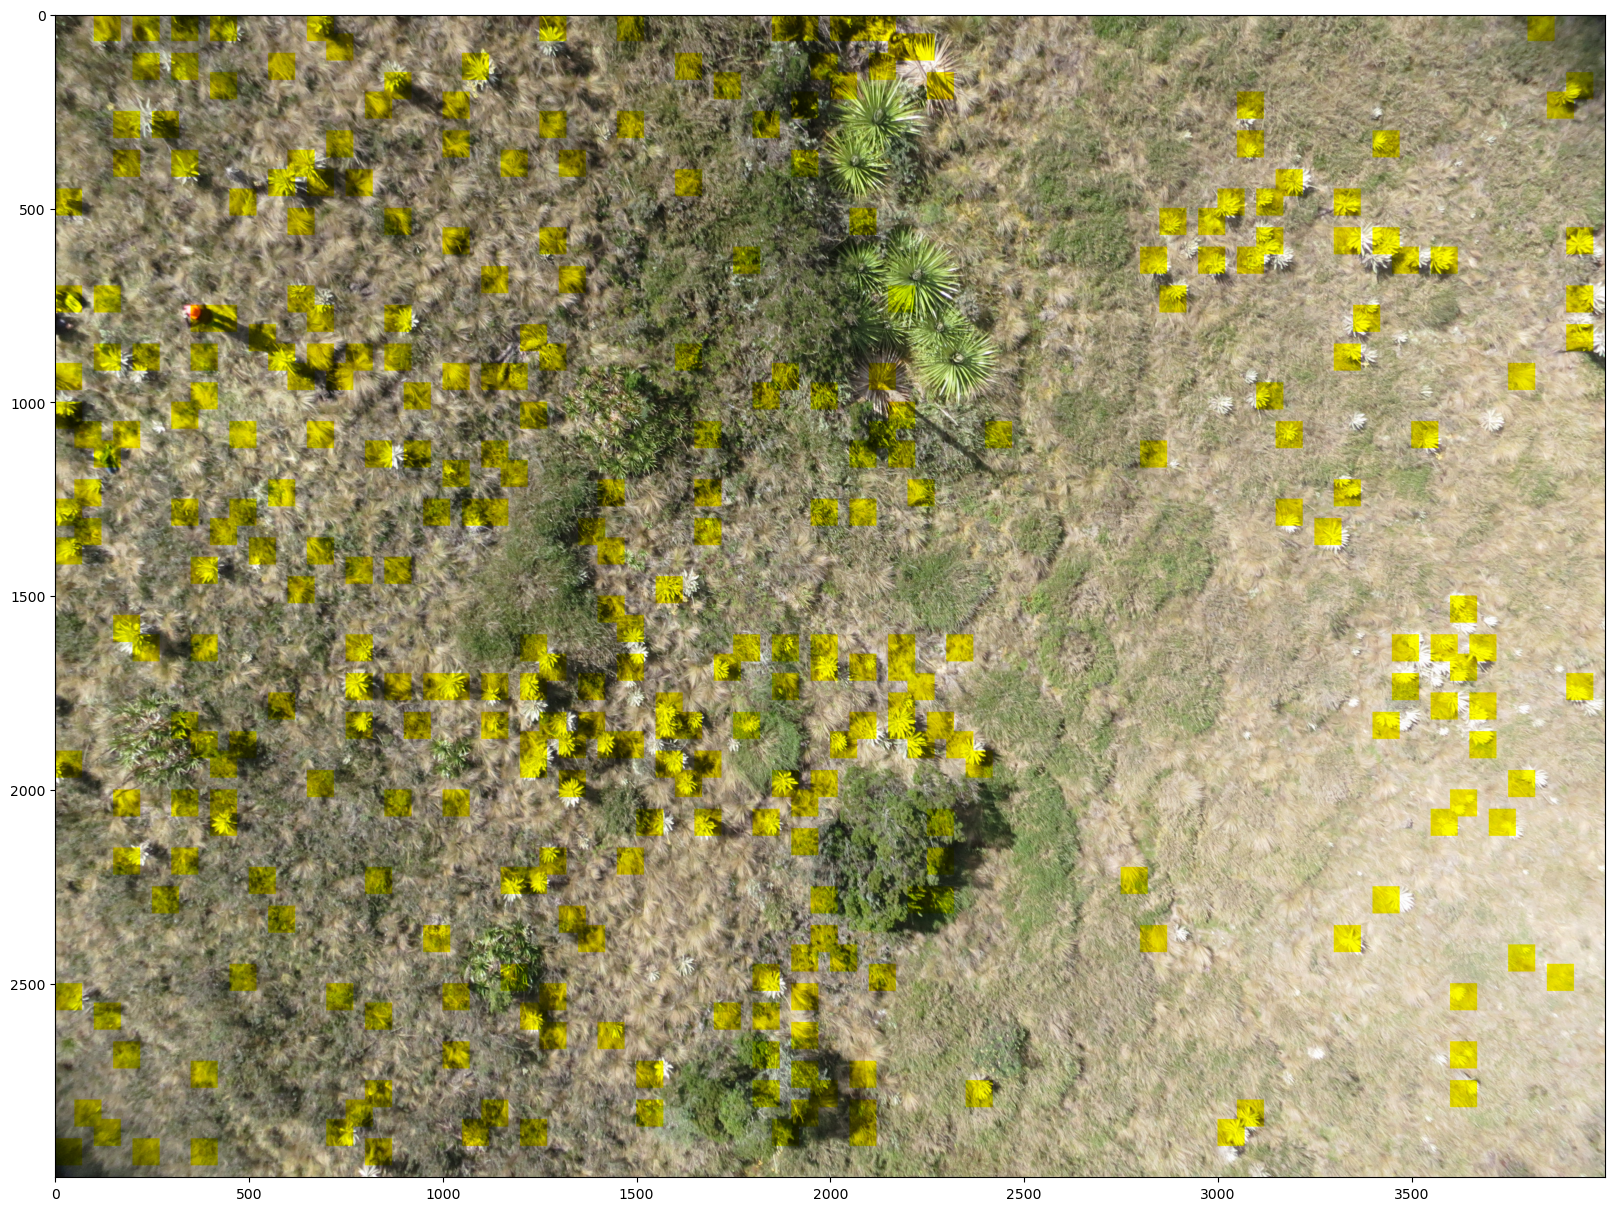

In [18]:
from tensorflow.keras.utils import load_img
urllib.request.urlretrieve('https://github.com/sergiomora03/AdvancedTopicsAnalytics/blob/main/notebooks/img/IMG_3451.JPG?raw=true', 'IMG_3451.JPG')
img = load_img('IMG_3451.JPG')
img = np.array(img)  
# Lo pasamos por nuestra imagen de prueba
x = np.array(img)
x2 = x

ni = x.shape[0]-50
mi = x.shape[1]-50

f1=0
f2=70
for i in range(1,ni,50):
    c1=0
    c2=70
    for j in range(1,mi,50):
        subi=x[f1:f2,c1:c2,]
        subi2=np.ndarray.flatten(subi).T/255.
        ns=subi2.shape[0]
        vec=subi2
        vec.shape=(ns,1)
        pred_P=(model_cp.predict(vec.T, verbose=0) > 0.5).astype(int)
        if(pred_P==1):
            x2[f1:f2,c1:c2,2]=0
        c1=c1+50
        c2=c2+50
    f1=f1+50
    f2=f2+50

plt.figure(figsize = (20,20))
plt.imshow(x2)